# Llama

This notebook uses an off the shelf Llama model to classify a news article into one of five bias labels. We freeze Llama and add a classification head to create a baseline Llama implementation before going on to LoRa in the next notebook. 

In [1]:
# For google colab
# Upload the folder containing this file to google drive if using colab.
import sys, os

# Checking if the notebook is opened in google colab
#If YES, mount the google drive and change the directory
if 'google.colab' in sys.modules:

    # mount google drive
    from google.colab import drive
    drive.mount('/content/drive')

    # change path to the folder
    path = '/content/drive/My Drive/CS5242Project'
    print(path)
    #os.chdir changes the current working directory
    os.chdir(path)
    !pwd


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import LambdaLR
from torch.utils.data import Dataset, DataLoader      

from transformers import AutoTokenizer

from sklearn.utils.class_weight import compute_class_weight

from skorch import NeuralNetClassifier
from skorch.dataset import ValidSplit
from skorch.callbacks import LRScheduler, EarlyStopping, EpochScoring
from skorch.helper import predefined_split

from functools import partial
import logging
from logging import StreamHandler


import time

from utils import set_device, load_dataset
from transformer_utils import TransformerNewsDataset, cosine_with_warmup_lr_lambda
from models.llama_base import LlamaClassifier

torch.manual_seed(42)
np.random.seed(42)

handler = StreamHandler()
formatter = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s')
handler.setFormatter(formatter)

logger = logging.getLogger()
if logger.hasHandlers():
    logger.handlers.clear()
logger.addHandler(handler)

device = set_device()
print('Using device:', device)

model_id = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
tokenizer = AutoTokenizer.from_pretrained(model_id)

datasets = {
    'combined': [
        'data/combined_transformers_train_preprocessed.csv', 
        'data/combined_transformers_test_preprocessed.csv'
        ],
    'base': [
        'data/transformers_train_preprocessed.csv', 
        'data/transformers_test_preprocessed.csv'
        ]
}

max_length = 128

for k, v in datasets.items():
    for i, t in enumerate(v):
        X, y , classes = load_dataset(t)
        datasets[k][i] = (X, y)
        datasets[k][i] = TransformerNewsDataset(datasets[k][i][0], datasets[k][i][1], tokenizer, max_len=max_length)

train, test = datasets['combined']

Using device: cuda


In [3]:
# Global settings

# tokenizer settings
max_length = 128

# validation dataset settings
USE_TEST_AS_VALID = False 

# learning rate and scheduler settings
lr = 1e-3
num_epochs = 30
num_cycles = 0.5
warmup_steps_scaler = 0.1
last_epoch = -1

# training settings
batch_size = 8
max_epochs = 30
loss_func = nn.CrossEntropyLoss
optimizer = torch.optim.AdamW

In [4]:
# Additional calculated variables

if USE_TEST_AS_VALID:
    train_split = predefined_split(test)
else:
    train_split = ValidSplit(0.2, stratified=True)

    
train_loader = DataLoader(train, batch_size=batch_size, shuffle=True)
total_steps = len(train_loader) * num_epochs
num_warmup_steps = int(warmup_steps_scaler * total_steps)

class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(train.labels), y=train.labels)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
unique_labels = np.unique(train.labels)

In [5]:
net = partial(NeuralNetClassifier,
    module=partial(LlamaClassifier, model_id=model_id, num_labels=len(unique_labels)),
    criterion=partial(loss_func, weight=class_weights_tensor),
    optimizer=optimizer,
    lr=lr,
    batch_size=batch_size,
    max_epochs=max_epochs,
    device=device,
    callbacks=[
        EpochScoring(scoring='f1_weighted', name='train_f1', lower_is_better=False, on_train=True),
        EpochScoring(scoring='accuracy', name='train_acc', lower_is_better=False, on_train=True),
        
        EpochScoring(scoring='f1_weighted', name='valid_f1', lower_is_better=False),
        EpochScoring(scoring='accuracy', name='valid_acc', lower_is_better=False),

        LRScheduler(
            policy=LambdaLR,
            lr_lambda=partial(
                cosine_with_warmup_lr_lambda, 
                num_warmup_steps=num_warmup_steps, 
                num_cyles=num_cycles
            ),
            last_epoch=last_epoch
                   ),
        EarlyStopping(monitor='valid_f1', patience=5, lower_is_better=False)
    ]
    )

net = net(train_split=train_split)

In [6]:
print('Training base dataset net')
net.fit(train, torch.tensor(train.labels))

Training base dataset net
  epoch    train_acc    train_f1    train_loss    valid_acc    valid_f1    valid_loss      lr       dur
-------  -----------  ----------  ------------  -----------  ----------  ------------  ------  --------
      1       0.3697      0.3529        1.6439       0.3781      0.3564        1.6095  0.0000  140.8860
      2       0.3690      0.3553        1.6400       0.3752      0.3590        1.6014  0.0000  141.0727
      3       0.3573      0.3522        1.6291       0.3679      0.3616        1.5880  0.0000  140.9800
      4       0.3566      0.3588        1.6140       0.3810      0.3803        1.5717  0.0000  141.1018
      5       0.3584      0.3649        1.5959       0.3956      0.3964        1.5529  0.0000  141.0809
      6       0.3679      0.3753        1.5750       0.4131      0.4125        1.5317  0.0000  141.2374
      7       0.3814      0.3887        1.5515       0.4380      0.4370        1.5085  0.0000  141.1113
      8       0.4001      0.4082      

<class 'skorch.classifier.NeuralNetClassifier'>[initialized](
  module_=LlamaClassifier(
    (llama): LlamaModel(
      (embed_tokens): Embedding(32000, 2048)
      (layers): ModuleList(
        (0-21): 22 x LlamaDecoderLayer(
          (self_attn): LlamaAttention(
            (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
            (k_proj): Linear(in_features=2048, out_features=256, bias=False)
            (v_proj): Linear(in_features=2048, out_features=256, bias=False)
            (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
          )
          (mlp): LlamaMLP(
            (gate_proj): Linear(in_features=2048, out_features=5632, bias=False)
            (up_proj): Linear(in_features=2048, out_features=5632, bias=False)
            (down_proj): Linear(in_features=5632, out_features=2048, bias=False)
            (act_fn): SiLU()
          )
          (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
          (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
        )
      )
      (norm): LlamaRMSNorm((2048,), eps=1e-05)
      (rotary_emb): LlamaRotaryEmbedding()
    )
    (classifier): Linear(in_features=2048, out_features=5, bias=True)
  ),
)

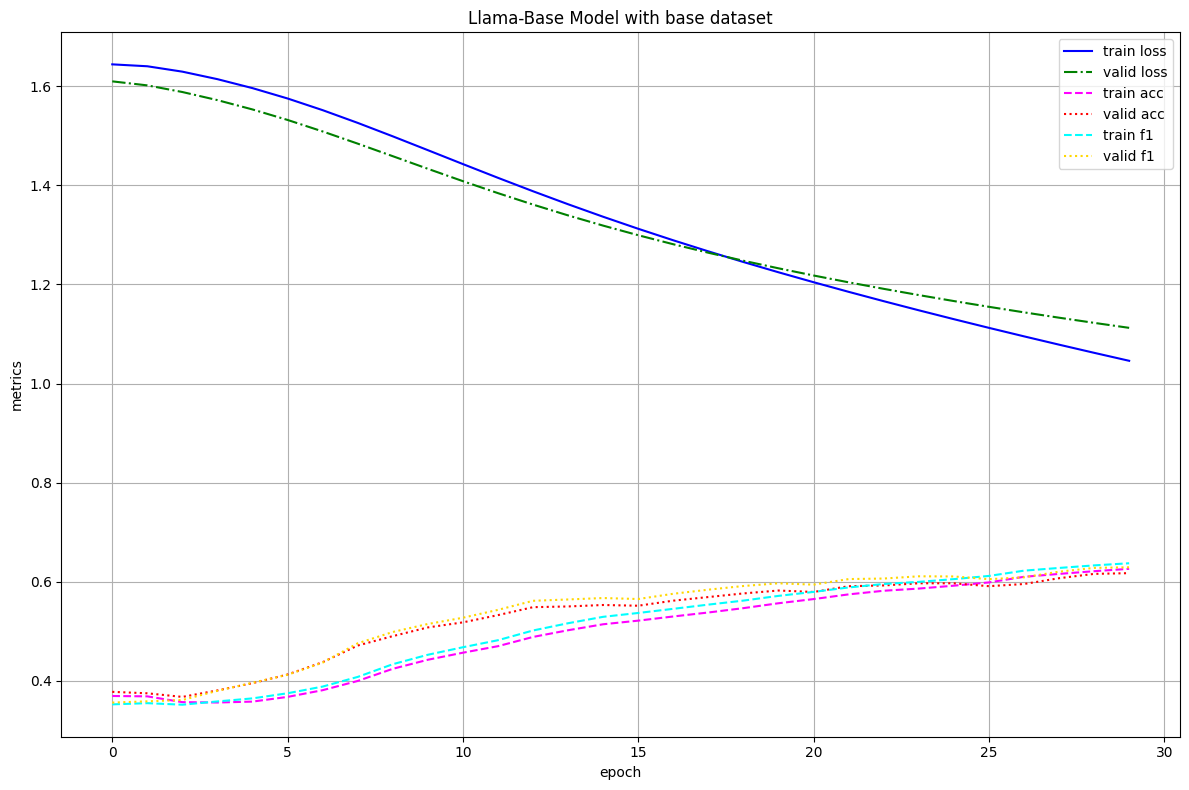

In [9]:
from utils import plot_result_curves

# Call this with the best BERT model found
plot_result_curves(net, 'Llama-Base Model with base dataset');

# Evaluation

Similar to BERT, we also see a performance increase - albeit not as significant - when using the combined dataset with the base TinyLlama model. Again we see both validation and train losses trending downwards still despite hitting the early stopping trigger. This does encourage us to try with LoRA tuning again, though we expect much longer training times given that the combined dataset took twice as long per epoch combined to the base dataset on this model.

In [7]:
y_pred = net.predict(test.embed_all())
y_prob = net.predict_proba(test.embed_all())

In [8]:
from utils import print_evaluation_report

print_evaluation_report(y_pred, test, classes, 'Llama-Base Base Dataset')

Llama-Base Base Dataset Accuracy: 57.06%
Llama-Base Base Dataset Weighted F1-score: 0.5844

Classification Report:
               precision    recall  f1-score   support

      center     0.3299    0.3855    0.3556        83
   lean left     0.4500    0.5081    0.4773       124
  lean right     0.3765    0.4444    0.4076        72
        left     0.8147    0.6397    0.7167       433
       right     0.4359    0.5862    0.5000       145

    accuracy                         0.5706       857
   macro avg     0.4814    0.5128    0.4914       857
weighted avg     0.6141    0.5706    0.5844       857



# Classification report summary

We do see a boost to the f1 (0.5844 vs 0.5375) and accuracy (57.06% vs 51.72%) scores on the combined dataset, though surprisingly it isn't as much as previous models. This could suggest that the model hasn't been able to generalize properly yet given the amount of epochs. Some parameter tuning may be done to help increase performance.

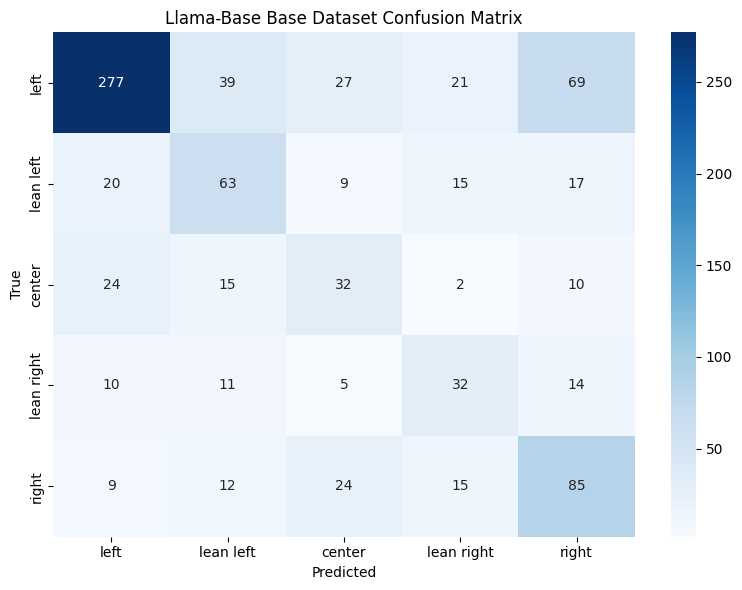

In [10]:
# Define correct label order
from utils import plot_confusion_matrix

plot_confusion_matrix(y_pred, test, classes, 'Llama-Base Base Dataset');

In [11]:
from utils import show_one_vs_rest_confusion_matrices

print('Confusion matrics for Llama-Base Base Dataset')
show_one_vs_rest_confusion_matrices(net, y_pred, test, classes)

Confusion matrics for Llama-Base Base Dataset

One-vs-Rest Confusion Matrix for class 'center':
[[709  65]
 [ 51  32]]

One-vs-Rest Confusion Matrix for class 'lean left':
[[656  77]
 [ 61  63]]

One-vs-Rest Confusion Matrix for class 'lean right':
[[732  53]
 [ 40  32]]

One-vs-Rest Confusion Matrix for class 'left':
[[361  63]
 [156 277]]

One-vs-Rest Confusion Matrix for class 'right':
[[602 110]
 [ 60  85]]


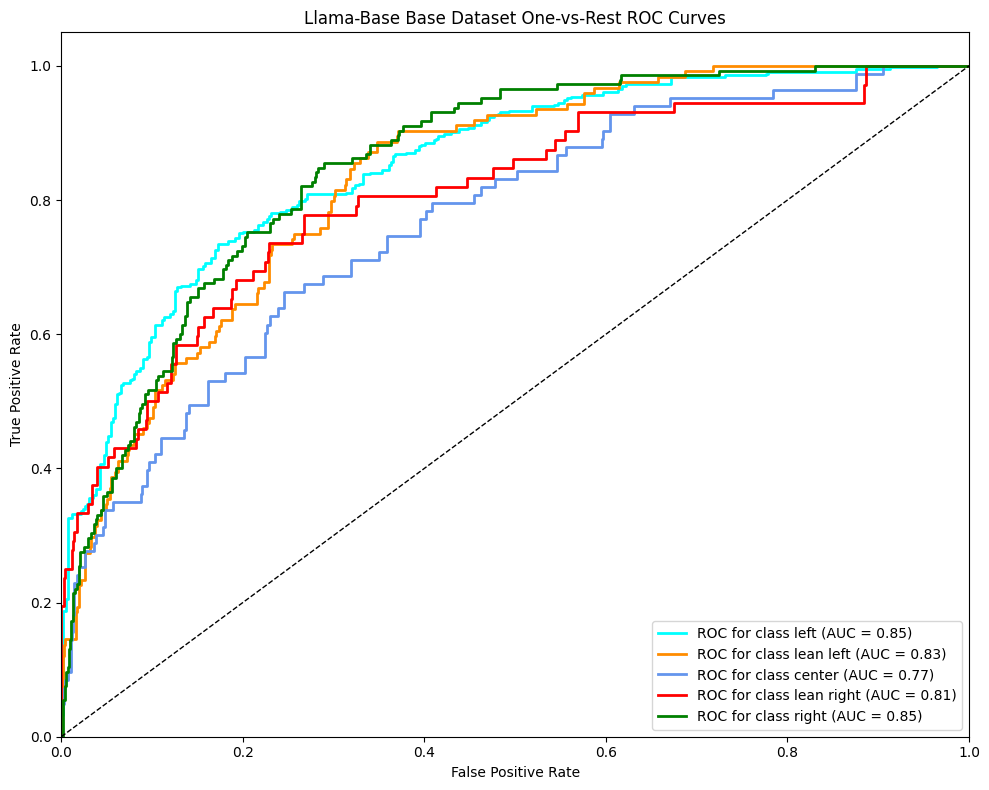

In [12]:
from utils import plot_roc


plot_roc(y_prob, net, test, classes, 'Llama-Base Base Dataset');

### Performance Metrics Evaluation Summary

| Model            | Accuracy | Weighted F1 |
|------------------|----------|-------------|
| base data        | 51.72    | 53.75       |
| combined data    | 57.06    | 58.44       |
